In [10]:


# --- Standard library ---
import os
import time
import random
import zipfile
import urllib.request
from pathlib import Path

# --- Numerical / data handling ---
import numpy as np
import pandas as pd

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Scikit-learn: preprocessing, splitting, metrics ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

# --- TensorFlow / Keras ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.layers import (
    SimpleRNN, LSTM, GRU, Dense, Dropout,
    Embedding, RepeatVector, TimeDistributed,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import cv2   # reads videos and extracts frames

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


sns.set_style("whitegrid")


# --- Environment check ---
print("TensorFlow version :", tf.__version__)
print("Keras version      :", keras.__version__)
print("NumPy version      :", np.__version__)
print("GPU available      :", tf.config.list_physical_devices("GPU"))

TensorFlow version : 2.20.0
Keras version      : 3.13.2
NumPy version      : 2.1.3
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [11]:
from google.colab import files
def save_plot(filename):

    path = f"{filename}.eps"
    plt.savefig(path, format='eps', dpi=600, bbox_inches='tight')
    files.download(path)
    print(f"Saved and downloaded: {path}")

In [12]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

In [4]:

import ssl
import urllib.error
from concurrent.futures import ThreadPoolExecutor

UCF_ROOT  = "https://www.crcv.ucf.edu/THUMOS14/UCF101/UCF101/"
VIDEO_DIR = Path.cwd() / "ucf101_videos"
VIDEO_DIR.mkdir(exist_ok=True)

CLASSES = ["Basketball", "Biking", "TennisSwing", "WalkingWithDog", "JumpRope"]

# Split by GROUP number (g01-g25), so near-duplicate scenes never span train/val/test
SPLIT_GROUPS    = {"test": range(1, 6), "val": range(6, 11), "train": range(11, 26)}
CLIPS_PER_GROUP = {"train": 2, "val": 3, "test": 3}

HEADERS = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                         "(KHTML, like Gecko) Chrome/120.0 Safari/537.36"}


def open_url(url):
    req = urllib.request.Request(url, headers=HEADERS)
    try:
        return urllib.request.urlopen(req, timeout=60)
    except urllib.error.HTTPError:
        raise                                   # 403/404 are server answers; don't retry
    except Exception:                           # certificate problem -> retry unverified
        return urllib.request.urlopen(req, context=ssl._create_unverified_context(), timeout=60)



try:
    with open_url(UCF_ROOT + "v_Biking_g01_c01.avi") as r:
        test_bytes = r.read()
    print(f"Test download OK ({len(test_bytes)/1e3:.0f} KB)")
except Exception as e:
    raise RuntimeError(f"Test download failed: {e}\n"
                       "The server is refusing this notebook. Use the Kaggle 'Add Data' fallback.")

#1. Build the manifest directly from filenames
rows = []
for label, cls in enumerate(CLASSES):
    for split, groups in SPLIT_GROUPS.items():
        for g in groups:
            for c in range(1, CLIPS_PER_GROUP[split] + 1):
                fname = f"v_{cls}_g{g:02d}_c{c:02d}.avi"
                rows.append(dict(fname=fname, cls=cls, label=label, group=g, clip=c,
                                 split=split, path=str(VIDEO_DIR / fname)))
manifest = pd.DataFrame(rows)


# 2. Download
def fetch(fname):
    dest = VIDEO_DIR / fname
    if dest.exists() and dest.stat().st_size > 0:
        return True
    try:
        with open_url(UCF_ROOT + fname) as r, open(dest, "wb") as f:
            f.write(r.read())
        return True
    except Exception:
        return False

print(f"Downloading {len(manifest)} clips...")
with ThreadPoolExecutor(max_workers=8) as ex:
    manifest["ok"] = list(ex.map(fetch, manifest["fname"]))

failed = manifest[~manifest["ok"]]
print(f"Failed downloads: {len(failed)}")
if len(failed):
    print(failed.groupby("cls").size().rename("failed clips per class").to_string())
    print("If one class fails completely, its name is probably wrong - change it in CLASSES.")

manifest = manifest[manifest["ok"]].drop(columns="ok").reset_index(drop=True)
manifest.to_csv(VIDEO_DIR / "manifest.csv", index=False)

# ---------- 3. Verify ----------
print("\nVideos per class and split:")
print(pd.crosstab(manifest["cls"], manifest["split"])[["train", "val", "test"]])
print("\nSize on disk: %.0f MB" % (sum(p.stat().st_size for p in VIDEO_DIR.glob("*.avi")) / 1e6))

cap = cv2.VideoCapture(manifest["path"][0])
print(f"\nExample video: {manifest['fname'][0]}")
print("  frames:", int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
      "| fps:", cap.get(cv2.CAP_PROP_FPS),
      "| size:", int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), "x", int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))
cap.release()

Test download OK (368 KB)
Failed downloads: 0

Videos per class and split:
split           train  val  test
cls                             
Basketball         30   15    15
Biking             30   15    15
JumpRope           30   15    15
TennisSwing        30   15    15
WalkingWithDog     30   15    15

Size on disk: 156 MB

Example video: v_Basketball_g01_c01.avi
  frames: 141 | fps: 29.97002997002997 | size: 320 x 240


Frames per video, by class:
                min  median  max
cls                             
Basketball       53   120.0  528
Biking          101   201.0  599
JumpRope        198   432.5  623
TennisSwing      62   134.5  335
WalkingWithDog   93   240.0  240

Video: v_Basketball_g01_c01.avi  |  total frames: 141
Chosen frame indices: [  0  15  31  46  62  77  93 108 124 140]
Sampled tensor shape: (10, 224, 224, 3) | dtype: uint8 | sampling time: 0.11 s


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: plot7_video_sample_frames.eps


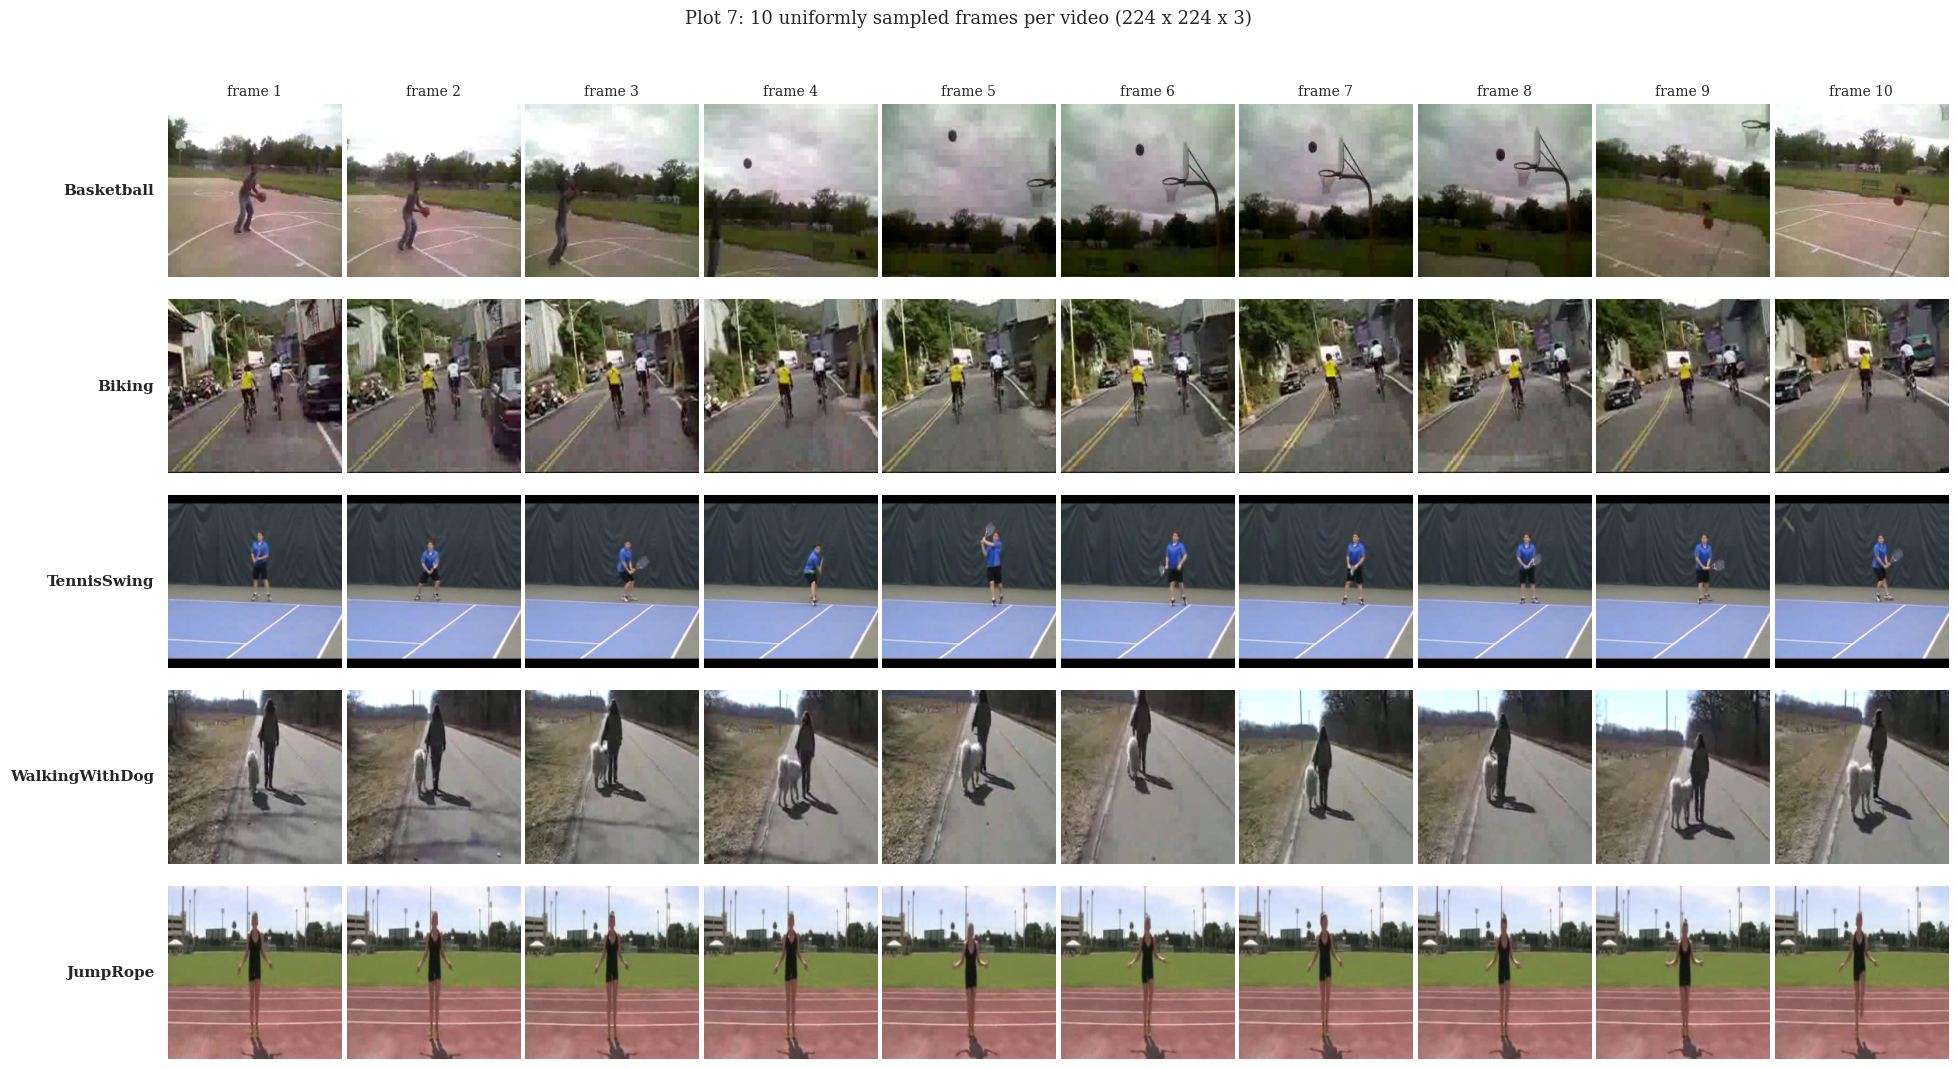

In [5]:


N_FRAMES = 10
IMG_SIZE = 224


def sample_frames(path, n_frames=N_FRAMES, size=IMG_SIZE):
    """Read a video, pick n_frames evenly spaced frames, resize each to size x size (RGB).
    Returns: frames (n_frames, size, size, 3) uint8, chosen indices, total frames in video."""
    cap = cv2.VideoCapture(path)
    frames = []
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frames.append(frame)
    cap.release()
    if len(frames) == 0:
        raise ValueError(f"No frames could be read from {path}")

    idx = np.linspace(0, len(frames) - 1, n_frames).astype(int)      # uniform sampling
    out = [cv2.resize(cv2.cvtColor(frames[i], cv2.COLOR_BGR2RGB), (size, size),
                      interpolation=cv2.INTER_AREA) for i in idx]     # BGR -> RGB, resize
    return np.stack(out).astype(np.uint8), idx, len(frames)



counts = []
for p in manifest["path"]:
    cap = cv2.VideoCapture(p)
    counts.append(int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
    cap.release()
manifest["n_frames"] = counts
print("Frames per video, by class:")
print(manifest.groupby("cls")["n_frames"].agg(["min", "median", "max"]).to_string())

# ---------- One example, with shapes ----------
t0 = time.time()
frames, idx, total = sample_frames(manifest["path"][0])
print(f"\nVideo: {manifest['fname'][0]}  |  total frames: {total}")
print("Chosen frame indices:", idx)
print("Sampled tensor shape:", frames.shape, "| dtype:", frames.dtype,
      f"| sampling time: {time.time() - t0:.2f} s")

# ---------- Plot 7: sampled frames, one train video per class ----------
fig, axes = plt.subplots(len(CLASSES), N_FRAMES, figsize=(2 * N_FRAMES, 2.2 * len(CLASSES)))
for r, cls in enumerate(CLASSES):
    row = manifest[(manifest["cls"] == cls) & (manifest["split"] == "train")].iloc[0]
    fr, _, _ = sample_frames(row["path"])
    for c in range(N_FRAMES):
        axes[r, c].imshow(fr[c])
        axes[r, c].axis("off")
        if r == 0:
            axes[r, c].set_title(f"frame {c + 1}", fontsize=10)
    axes[r, 0].text(-0.08, 0.5, cls, transform=axes[r, 0].transAxes,
                    ha="right", va="center", fontsize=11, fontweight="bold")
fig.suptitle("Plot 7: 10 uniformly sampled frames per video (224 x 224 x 3)", fontsize=13)
plt.subplots_adjust(left=0.10, right=0.99, top=0.90, bottom=0.02, wspace=0.03, hspace=0.05)
save_plot("plot7_video_sample_frames")
plt.show()

In [6]:

base_cnn = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                       include_top=False,       # remove the ImageNet classifier
                       weights="imagenet",      # pretrained weights
                       pooling="avg")           # global average pooling -> one vector per frame
base_cnn.trainable = False                      # frozen: the CNN is never trained here

D = base_cnn.output_shape[-1]
print("CNN output per frame :", base_cnn.output_shape, "-> feature dimension D =", D)
print(f"CNN parameters       : {base_cnn.count_params():,} (all frozen)")

# ---------- 2. Extract features for every video (cached on disk) ----------
FEAT_FILE = Path.cwd() / "video_features_mobilenetv2.npz"


def extract_features(paths, chunk=16):
    """paths -> features of shape (n_videos, N_FRAMES, D). Processes `chunk` videos at a time."""
    feats = []
    for s in range(0, len(paths), chunk):
        batch = [sample_frames(p)[0] for p in paths[s:s + chunk]]        # list of (10, 224, 224, 3)
        x = np.concatenate(batch, axis=0).astype("float32")              # (chunk*10, 224, 224, 3)
        x = preprocess_input(x)                                          # scale pixels to [-1, 1]
        f = base_cnn.predict(x, batch_size=64, verbose=0)                # (chunk*10, D)
        feats.append(f.reshape(len(batch), N_FRAMES, -1))                # (chunk, 10, D)
        print(f"  processed {min(s + chunk, len(paths))}/{len(paths)} videos", end="\r")
    return np.concatenate(feats)


if FEAT_FILE.exists():
    print("\nLoading cached features...")
    cache = np.load(FEAT_FILE, allow_pickle=True)
    VX_all = cache["X"]
    assert list(cache["fnames"]) == list(manifest["fname"]), "Cache does not match manifest - delete the .npz"
else:
    print("\nExtracting features (decoding video + CNN forward pass)...")
    t0 = time.time()
    VX_all = extract_features(list(manifest["path"]))
    print(f"\nExtraction time: {time.time() - t0:.0f} s")
    np.savez_compressed(FEAT_FILE, X=VX_all, fnames=manifest["fname"].values)

# ---------- 3. Split by the manifest (train / val / test by group) ----------
vy_all = manifest["label"].values.astype(np.int64)
masks = {s: (manifest["split"] == s).values for s in ["train", "val", "test"]}
VX_train, vy_train = VX_all[masks["train"]], vy_all[masks["train"]]
VX_val,   vy_val   = VX_all[masks["val"]],   vy_all[masks["val"]]
VX_test,  vy_test  = VX_all[masks["test"]],  vy_all[masks["test"]]

# ---------- 4. Required observation ----------
print("\nCNN feature dimension D :", D)
print("Tensor shape given to the recurrent network (B, 10, D):")
print("  Training  :", VX_train.shape)
print("  Validation:", VX_val.shape)
print("  Testing   :", VX_test.shape)
print("Number of action classes:", len(CLASSES), CLASSES)

# ---------- 5. Sanity checks ----------
print("\nAny NaN in features:", bool(np.isnan(VX_all).any()))
print(f"Feature range: min={VX_all.min():.3f}, max={VX_all.max():.3f}, mean={VX_all.mean():.3f}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
CNN output per frame : (None, 1280) -> feature dimension D = 1280
CNN parameters       : 2,257,984 (all frozen)

Extracting features (decoding video + CNN forward pass)...
  processed 300/300 videos
Extraction time: 69 s

CNN feature dimension D : 1280
Tensor shape given to the recurrent network (B, 10, D):
  Training  : (150, 10, 1280)
  Validation: (75, 10, 1280)
  Testing   : (75, 10, 1280)
Number of action classes: 5 ['Basketball', 'Biking', 'TennisSwing', 'WalkingWithDog', 'JumpRope']

Any NaN in features: False
Feature range: min=0.000, max=5.551, mean=0.479


Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ frame_features (InputLayer)     │ (None, 10, 1280)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_lstm (LSTM)                 │ (None, 32)             │       168,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 504,689 (1.93 MB)

 Trainable params: 168,229 (657.14 KB)

 Non-trainable params: 0 (0.00 B)

...

 Optimizer params: 252,620 (986.80 KB)


           Parameters  Training time (s)  Final train acc (%)  Final val acc (%)  Best val acc (%)  Final val loss
CNN-LSTM    168229.0                6.3                100.0              81.33              84.0          0.6113
CNN-GRU     126309.0                5.5                100.0              80.00              84.0          0.5155

Selected architecture (highest mean val accuracy over last 5 epochs): CNN-LSTM


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: plot8_video_training_validation.eps


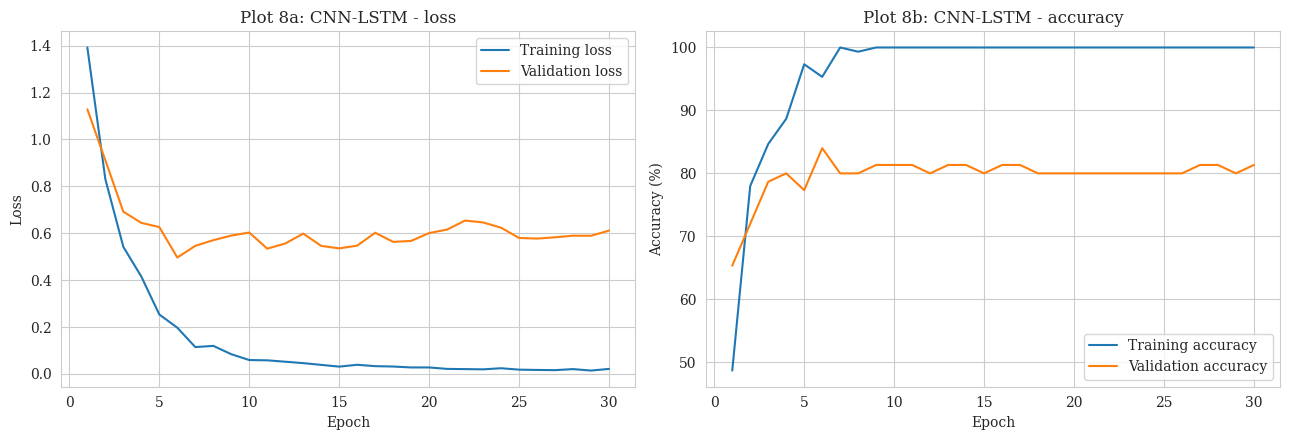

In [7]:


NUM_ACTIONS  = len(CLASSES)          # 5
V_UNITS      = 32                    # lab: 32 recurrent units
V_DROPOUT    = 0.3                   # extra regularisation (only 150 training videos)
V_LR         = 1e-3
V_BATCH      = 16                    # smaller batch -> more weight updates on a tiny dataset
V_EPOCHS     = 30

VIDEO_LAYERS = {"CNN-LSTM": LSTM, "CNN-GRU": GRU}
video_results, video_histories, video_models = {}, {}, {}


def build_video_model(kind):
    """(10, D) feature sequence -> LSTM/GRU(32) -> Dropout -> Dense(5, softmax)."""
    keras.utils.set_random_seed(SEED)
    inp = Input(shape=(N_FRAMES, D), name="frame_features")
    x = VIDEO_LAYERS[kind](V_UNITS, name=kind.lower().replace("-", "_"))(inp)
    x = Dropout(V_DROPOUT)(x)
    out = Dense(NUM_ACTIONS, activation="softmax")(x)
    model = Model(inp, out, name=kind.replace("-", "_"))
    model.compile(optimizer=Adam(learning_rate=V_LR),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


def train_video_model(kind):
    build_video_model(kind).fit(VX_train[:32], vy_train[:32], epochs=1, verbose=0)   # warm-up
    model = build_video_model(kind)
    start = time.time()
    hist = model.fit(VX_train, vy_train, validation_data=(VX_val, vy_val),
                     epochs=V_EPOCHS, batch_size=V_BATCH, verbose=0)
    elapsed = time.time() - start
    video_models[kind], video_histories[kind] = model, hist.history
    video_results[kind] = {"params": model.count_params(), "train_time_s": elapsed}
    return model


for kind in ["CNN-LSTM", "CNN-GRU"]:
    m = train_video_model(kind)
    m.summary()


summary_v = pd.DataFrame({
    k: {"Parameters": video_results[k]["params"],
        "Training time (s)": round(video_results[k]["train_time_s"], 1),
        "Final train acc (%)": round(video_histories[k]["accuracy"][-1] * 100, 2),
        "Final val acc (%)":   round(video_histories[k]["val_accuracy"][-1] * 100, 2),
        "Best val acc (%)":    round(max(video_histories[k]["val_accuracy"]) * 100, 2),
        "Final val loss":      round(video_histories[k]["val_loss"][-1], 4)}
    for k in VIDEO_LAYERS}).T
print("\n", summary_v.to_string())

# Mean of the last 5 epochs is less noisy than the last epoch alone (75 val videos = 1.3% per video)
score = {k: np.mean(video_histories[k]["val_accuracy"][-5:]) for k in VIDEO_LAYERS}
SELECTED = max(score, key=score.get)
print(f"\nSelected architecture (highest mean val accuracy over last 5 epochs): {SELECTED}")


def plot_video_history(tag):
    h = video_histories[tag]
    ep = np.arange(1, len(h["loss"]) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
    ax[0].plot(ep, h["loss"], label="Training loss")
    ax[0].plot(ep, h["val_loss"], label="Validation loss")
    ax[0].set(title=f"Plot 8a: {tag} - loss", xlabel="Epoch", ylabel="Loss")
    ax[1].plot(ep, np.array(h["accuracy"]) * 100, label="Training accuracy")
    ax[1].plot(ep, np.array(h["val_accuracy"]) * 100, label="Validation accuracy")
    ax[1].set(title=f"Plot 8b: {tag} - accuracy", xlabel="Epoch", ylabel="Accuracy (%)")
    for a in ax:
        a.legend()
    plt.tight_layout()
    save_plot("plot8_video_training_validation")
    plt.show()

plot_video_history(SELECTED)

Main model (selected on validation): CNN-LSTM

                       CNN-LSTM    CNN-GRU
Accuracy (%)              84.00      80.00
Macro Precision (%)       84.98      80.02
Macro Recall (%)          84.00      80.00
Macro F1 (%)              83.89      79.94
Trainable parameters  168229.00  126309.00
Training time (s)          6.35       5.46


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: plot9_video_confusion_matrix.eps


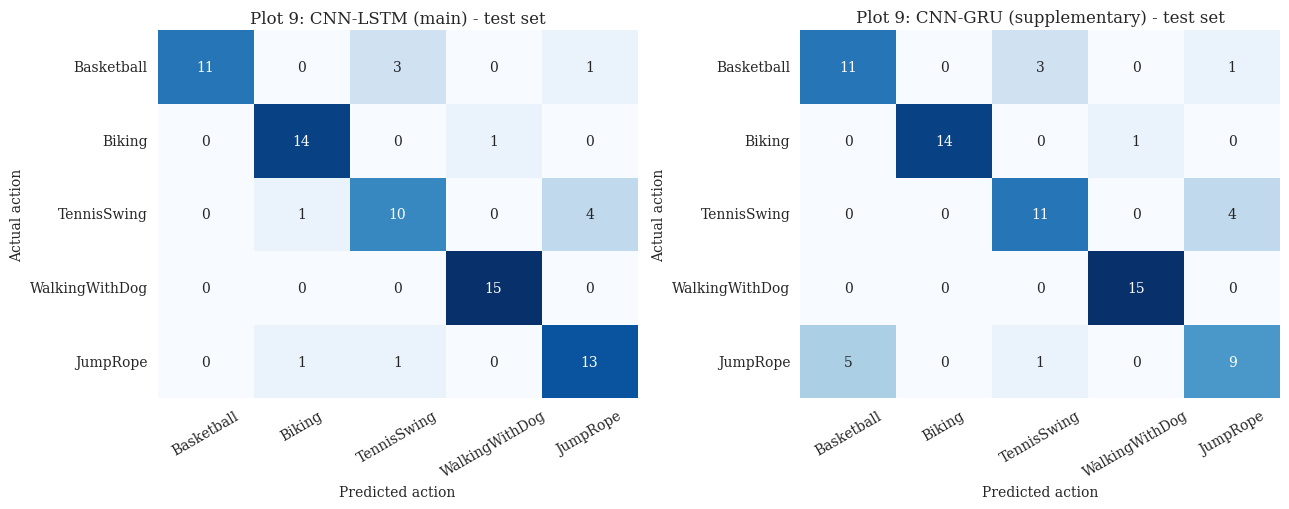


Per-action recall (%):
                CNN-LSTM  CNN-GRU
Basketball          73.3     73.3
Biking              93.3     93.3
TennisSwing         66.7     73.3
WalkingWithDog     100.0    100.0
JumpRope            86.7     60.0

CNN-LSTM - misclassified 12 of 75 test videos
  Basketball -> TennisSwing: 3
  Basketball -> JumpRope: 1
  Biking -> WalkingWithDog: 1
  TennisSwing -> Biking: 1
  TennisSwing -> JumpRope: 4
  JumpRope -> Biking: 1
  JumpRope -> TennisSwing: 1

CNN-GRU - misclassified 15 of 75 test videos
  Basketball -> TennisSwing: 3
  Basketball -> JumpRope: 1
  Biking -> WalkingWithDog: 1
  TennisSwing -> JumpRope: 4
  JumpRope -> Basketball: 5
  JumpRope -> TennisSwing: 1

Example predictions (CNN-LSTM):
  v_JumpRope_g05_c02.avi
    Predicted class : JumpRope
    Actual class    : JumpRope
    Confidence      : 0.98   (correct)
  v_WalkingWithDog_g03_c02.avi
    Predicted class : WalkingWithDog
    Actual class    : WalkingWithDog
    Confidence      : 0.97   (correct)
  v

In [8]:


def evaluate_video(tag):
    probs  = video_models[tag].predict(VX_test, verbose=0)      # (75, 5) class probabilities
    y_pred = probs.argmax(axis=1)
    video_results[tag].update({
        "accuracy":  accuracy_score(vy_test, y_pred) * 100,
        "precision": precision_score(vy_test, y_pred, average="macro", zero_division=0) * 100,
        "recall":    recall_score(vy_test, y_pred, average="macro", zero_division=0) * 100,
        "f1":        f1_score(vy_test, y_pred, average="macro", zero_division=0) * 100,
        "cm":        confusion_matrix(vy_test, y_pred, labels=range(NUM_ACTIONS)),
        "y_pred":    y_pred,
        "probs":     probs,
    })

for tag in ["CNN-LSTM", "CNN-GRU"]:
    evaluate_video(tag)

# ---------- Test-set metrics ----------
video_df = pd.DataFrame({
    tag: {"Accuracy (%)":        video_results[tag]["accuracy"],
          "Macro Precision (%)": video_results[tag]["precision"],
          "Macro Recall (%)":    video_results[tag]["recall"],
          "Macro F1 (%)":        video_results[tag]["f1"],
          "Trainable parameters": video_results[tag]["params"],
          "Training time (s)":   video_results[tag]["train_time_s"]}
    for tag in ["CNN-LSTM", "CNN-GRU"]})
print(f"Main model (selected on validation): {SELECTED}\n")
print(video_df.round(2).to_string())

# ---------- Plot 9: confusion matrices ----------
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
order = [SELECTED] + [t for t in ["CNN-LSTM", "CNN-GRU"] if t != SELECTED]
for ax, tag in zip(axes, order):
    sns.heatmap(video_results[tag]["cm"], annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
    role = "main" if tag == SELECTED else "supplementary"
    ax.set(title=f"Plot 9: {tag} ({role}) - test set", xlabel="Predicted action", ylabel="Actual action")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
save_plot("plot9_video_confusion_matrix")
plt.show()

# ---------- Per-class recall and most frequent errors ----------
recall_v = pd.DataFrame({
    tag: video_results[tag]["cm"].diagonal() / video_results[tag]["cm"].sum(axis=1) * 100
    for tag in order}, index=CLASSES)
print("\nPer-action recall (%):")
print(recall_v.round(1).to_string())

for tag in order:
    cm = video_results[tag]["cm"].copy()
    np.fill_diagonal(cm, 0)
    print(f"\n{tag} - misclassified {cm.sum()} of {len(vy_test)} test videos")
    for a, p in zip(*np.nonzero(cm)):
        print(f"  {CLASSES[a]} -> {CLASSES[p]}: {cm[a, p]}")


main = video_results[SELECTED]
test_meta = manifest[masks["test"]].reset_index(drop=True)
rng_v = np.random.default_rng(SEED)
show = rng_v.choice(len(vy_test), size=8, replace=False)

print(f"\nExample predictions ({SELECTED}):")
for i in show:
    pred, true = main["y_pred"][i], vy_test[i]
    print(f"  {test_meta['fname'][i]}\n"
          f"    Predicted class : {CLASSES[pred]}\n"
          f"    Actual class    : {CLASSES[true]}\n"
          f"    Confidence      : {main['probs'][i, pred]:.2f}   "
          f"{'(correct)' if pred == true else '(WRONG)'}")


wrong = np.where(main["y_pred"] != vy_test)[0]
correct = np.where(main["y_pred"] == vy_test)[0]
print(f"\nMean confidence when correct: {main['probs'][correct, main['y_pred'][correct]].mean():.2f}")
if len(wrong):
    print(f"Mean confidence when wrong  : {main['probs'][wrong, main['y_pred'][wrong]].mean():.2f}")
    print("\nMisclassified test videos:")
    for i in wrong:
        print(f"  {test_meta['fname'][i]:<34} actual={CLASSES[vy_test[i]]:<15} "
              f"predicted={CLASSES[main['y_pred'][i]]:<15} conf={main['probs'][i, main['y_pred'][i]]:.2f}")

Train (7000, 6) | Val (1500, 6) | Test (1500, 6)
Example  input: [1 7 6 4 4 8] | decoder input: [0 8 4 4 6 7] | target: [8 4 4 6 7 1]


Model: "seq2seq_reverse"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_embedding       │ (None, 6, 16)     │        160 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_embedding       │ (None, 6, 16)     │        160 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 128),     │     74,240 │ enc_embedding[0]… │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ (None, 6, 128)    │     74,240 │ dec_embedding[0]… │
│                     │                   │            │ encoder_lstm[0][… │
│                     │                   │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 6, 10)     │      1,290 │ decoder_lstm[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 150,090 (586.29 KB)

 Trainable params: 150,090 (586.29 KB)

 Non-trainable params: 0 (0.00 B)


Training time: 47.5 s | parameters: 150,090
Final training loss: 0.0004 | final validation loss: 0.0006


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: seq2seq_training_validation.eps


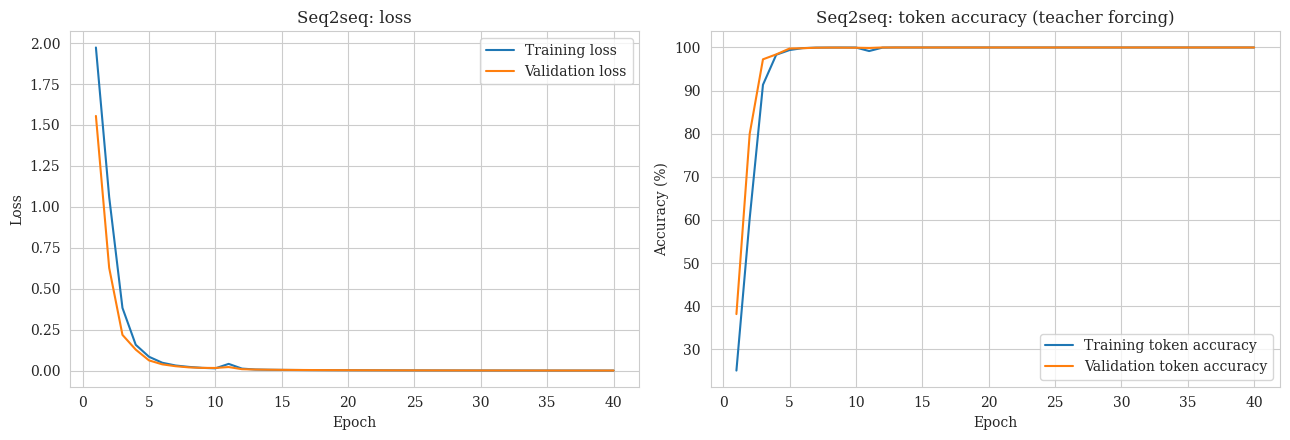


Test-set results (autoregressive decoding)
  Token accuracy    : 100.00%
  Sequence accuracy : 100.00%
  (teacher-forced token accuracy for comparison: 100.00%)
  If errors were independent, expected sequence accuracy = 100.00%  (= token accuracy ^ 6)

Accuracy per output position: {1: np.float64(100.0), 2: np.float64(100.0), 3: np.float64(100.0), 4: np.float64(100.0), 5: np.float64(100.0), 6: np.float64(100.0)}

  Sample     Input sequence    Expected output   Predicted output Correct
      1 [7, 9, 6, 8, 3, 4] [4, 3, 8, 6, 9, 7] [4, 3, 8, 6, 9, 7]     yes
      2 [7, 8, 1, 4, 8, 2] [2, 8, 4, 1, 8, 7] [2, 8, 4, 1, 8, 7]     yes
      3 [4, 5, 1, 9, 4, 8] [8, 4, 9, 1, 5, 4] [8, 4, 9, 1, 5, 4]     yes
      4 [4, 4, 9, 8, 5, 5] [5, 5, 8, 9, 4, 4] [5, 5, 8, 9, 4, 4]     yes
      5 [8, 7, 9, 3, 2, 2] [2, 2, 3, 9, 7, 8] [2, 2, 3, 9, 7, 8]     yes
      6 [5, 3, 8, 8, 2, 9] [9, 2, 8, 8, 3, 5] [9, 2, 8, 8, 3, 5]     yes
      7 [6, 3, 2, 2, 5, 1] [1, 5, 2, 2, 3, 6] [1, 5, 2, 2, 3, 6]     y

In [9]:


# ---------- Configuration ----------
S_VOCAB  = 10
S_LEN    = 6
S_N      = 10000
S_EMB    = 16
S_UNITS  = 128
S_EPOCHS = 40
S_BATCH  = 64
START    = 0


rng_s = np.random.default_rng(SEED)
Xs = rng_s.integers(1, S_VOCAB, size=(S_N, S_LEN)).astype(np.int32)       # e.g. [3 8 1 5 2 7]
Ys = Xs[:, ::-1].copy()                                                    # reversed: [7 2 5 1 8 3]
# Teacher forcing: the decoder is FED <start> + the true output shifted right by one position
Ds = np.concatenate([np.full((S_N, 1), START, dtype=np.int32), Ys[:, :-1]], axis=1)

n_tr, n_va = int(0.70 * S_N), int(0.15 * S_N)
Xtr, Dtr, Ytr = Xs[:n_tr], Ds[:n_tr], Ys[:n_tr]
Xva, Dva, Yva = Xs[n_tr:n_tr + n_va], Ds[n_tr:n_tr + n_va], Ys[n_tr:n_tr + n_va]
Xte, Dte, Yte = Xs[n_tr + n_va:], Ds[n_tr + n_va:], Ys[n_tr + n_va:]
print(f"Train {Xtr.shape} | Val {Xva.shape} | Test {Xte.shape}")
print("Example  input:", Xtr[0], "| decoder input:", Dtr[0], "| target:", Ytr[0])



def build_seq2seq():
    keras.utils.set_random_seed(SEED)
    # Encoder: reads the input and compresses it into its final states (h, c) = the "context"
    enc_in  = Input(shape=(S_LEN,), name="encoder_input")
    enc_emb = Embedding(S_VOCAB, S_EMB, name="enc_embedding")(enc_in)
    _, h, c = LSTM(S_UNITS, return_state=True, name="encoder_lstm")(enc_emb)
    # Decoder: starts from the encoder's context and predicts one output token per step
    dec_in  = Input(shape=(S_LEN,), name="decoder_input")
    dec_emb = Embedding(S_VOCAB, S_EMB, name="dec_embedding")(dec_in)
    dec_seq = LSTM(S_UNITS, return_sequences=True, name="decoder_lstm")(dec_emb, initial_state=[h, c])
    out     = Dense(S_VOCAB, activation="softmax", name="output")(dec_seq)
    model = Model([enc_in, dec_in], out, name="seq2seq_reverse")
    model.compile(optimizer=Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

seq_model = build_seq2seq()
seq_model.summary()

start = time.time()
seq_hist = seq_model.fit([Xtr, Dtr], Ytr, validation_data=([Xva, Dva], Yva),
                         epochs=S_EPOCHS, batch_size=S_BATCH, verbose=0)
seq_time = time.time() - start
sh = seq_hist.history
print(f"\nTraining time: {seq_time:.1f} s | parameters: {seq_model.count_params():,}")
print(f"Final training loss: {sh['loss'][-1]:.4f} | final validation loss: {sh['val_loss'][-1]:.4f}")


ep = np.arange(1, S_EPOCHS + 1)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(ep, sh["loss"], label="Training loss")
ax[0].plot(ep, sh["val_loss"], label="Validation loss")
ax[0].set(title="Seq2seq: loss", xlabel="Epoch", ylabel="Loss")
ax[1].plot(ep, np.array(sh["accuracy"]) * 100, label="Training token accuracy")
ax[1].plot(ep, np.array(sh["val_accuracy"]) * 100, label="Validation token accuracy")
ax[1].set(title="Seq2seq: token accuracy (teacher forcing)", xlabel="Epoch", ylabel="Accuracy (%)")
for a in ax:
    a.legend()
plt.tight_layout()
save_plot("seq2seq_training_validation")
plt.show()



def decode(enc_x):
    """Greedy autoregressive decoding. No true targets are used."""
    n = len(enc_x)
    dec = np.zeros((n, S_LEN), dtype=np.int32)
    dec[:, 0] = START
    pred = np.zeros((n, S_LEN), dtype=np.int32)
    for t in range(S_LEN):
        probs = seq_model.predict([enc_x, dec], verbose=0)     # (n, S_LEN, S_VOCAB)
        pred[:, t] = probs[:, t].argmax(axis=-1)               # token predicted at step t
        if t + 1 < S_LEN:
            dec[:, t + 1] = pred[:, t]                         # feed it back as the next input
    return pred

pred_te = decode(Xte)


token_acc = (pred_te == Yte).mean() * 100
seq_acc   = (pred_te == Yte).all(axis=1).mean() * 100
tf_loss, tf_acc = seq_model.evaluate([Xte, Dte], Yte, verbose=0)

print("\nTest-set results (autoregressive decoding)")
print(f"  Token accuracy    : {token_acc:.2f}%")
print(f"  Sequence accuracy : {seq_acc:.2f}%")
print(f"  (teacher-forced token accuracy for comparison: {tf_acc * 100:.2f}%)")
print(f"  If errors were independent, expected sequence accuracy = "
      f"{(token_acc / 100) ** S_LEN * 100:.2f}%  (= token accuracy ^ {S_LEN})")

pos_acc = (pred_te == Yte).mean(axis=0) * 100
print("\nAccuracy per output position:", dict(zip(range(1, S_LEN + 1), pos_acc.round(1))))


ex = pd.DataFrame({
    "Sample": range(1, 11),
    "Input sequence": [list(x) for x in Xte[:10]],
    "Expected output": [list(y) for y in Yte[:10]],
    "Predicted output": [list(p) for p in pred_te[:10]],
    "Correct": ["yes" if (p == y).all() else "NO" for p, y in zip(pred_te[:10], Yte[:10])],
})
print("\n", ex.to_string(index=False))


seq_table = pd.DataFrame({"Seq2seq (encoder-decoder LSTM)": {
    "Token accuracy (%)": token_acc, "Sequence accuracy (%)": seq_acc,
    "Final training loss": sh["loss"][-1], "Final validation loss": sh["val_loss"][-1],
    "Parameters": seq_model.count_params(), "Training time (s)": seq_time}})
print("\n", seq_table.round(4).to_string())